In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/Students Performance Dataset.json
/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/metadata.xlsx
/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/Students_Grading_Dataset_Biased.csv
/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/Students Performance Dataset.csv
/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/Students_Grading_Dataset_Biased.json


In [2]:
data = pd.read_csv("/kaggle/input/datasets/mahmoudelhemaly/students-grading-dataset/Students Performance Dataset.csv")

# 1. Understainding Data

In [3]:
df = pd.DataFrame(data)

In [4]:
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,...,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,...,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,...,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,...,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,...,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5


In [5]:
df.shape

(5000, 23)

In [6]:
df.columns

Index(['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age',
       'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
       'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week',
       'Extracurricular_Activities', 'Internet_Access_at_Home',
       'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)',
       'Sleep_Hours_per_Night'],
      dtype='object')

In [7]:
print(f"Number of duplicates : {df.duplicated().sum()}")

Number of duplicates : 0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              5000 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             5000 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

In [9]:
# Display the number of missing values in each column
df.isnull().sum()[df.isnull().sum() > 0]

Parent_Education_Level    1025
dtype: int64

## Check spelling

In [10]:
#check gender
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [11]:
# Department names
df['Department'].unique()

array(['Mathematics', 'Business', 'Engineering', 'CS'], dtype=object)

##### change CS to Computer Science to be more clear

In [12]:
df['Department'] = df['Department'].replace({"CS":"Computer Science"})

In [13]:
df['Grade'].unique()

array(['F', 'B', 'D', 'C', 'A'], dtype=object)

In [14]:
# Parent Education Level names
df['Parent_Education_Level'].unique()

array(["Master's", 'High School', nan, "Bachelor's", 'PhD'], dtype=object)

In [15]:
df['Parent_Education_Level'].value_counts()

Parent_Education_Level
Bachelor's     1020
PhD            1012
Master's       1000
High School     943
Name: count, dtype: int64

##### As we can see, there are null values in the column, as well as "None" as a string. We want to convert both to "Unknown"


In [16]:
# Family_Income_Level check consistency
df['Family_Income_Level'].unique()

array(['Medium', 'Low', 'High'], dtype=object)

In [17]:
df['Extracurricular_Activities'].unique()

array(['Yes', 'No'], dtype=object)

## Numerical columns

In [18]:
numeric_columns = df.select_dtypes(include = ['number']).columns
numeric_columns

Index(['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
       'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Study_Hours_per_Week',
       'Stress_Level (1-10)', 'Sleep_Hours_per_Night'],
      dtype='object')

#### Check for the existence of negative values.

In [19]:
(df[numeric_columns] < 0).sum()

Age                      0
Attendance (%)           0
Midterm_Score            0
Final_Score              0
Assignments_Avg          0
Quizzes_Avg              0
Participation_Score      0
Projects_Score           0
Total_Score              0
Study_Hours_per_Week     0
Stress_Level (1-10)      0
Sleep_Hours_per_Night    0
dtype: int64

No negative values

#### see if there is any entry error or value out of range

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,21.048400,1.989786,18.000,19.000000,21.00000,23.000000,24.0000
Attendance (%),5000.0,75.356076,14.392716,50.010,62.945000,75.67000,87.862500,100.0000
Midterm_Score,5000.0,70.701924,17.436325,40.000,55.707500,70.86000,85.760000,99.9900
Final_Score,5000.0,69.546552,17.108996,40.010,54.697500,69.48500,83.922500,99.9800
Assignments_Avg,5000.0,74.956320,14.404287,50.000,62.340000,75.09000,87.352500,99.9900
Quizzes_Avg,5000.0,74.836214,14.423848,50.000,62.357500,74.90500,87.292500,99.9900
Participation_Score,5000.0,49.963720,28.989785,0.000,25.075000,49.60000,75.500000,100.0000
Projects_Score,5000.0,74.783050,14.542430,50.000,61.970000,74.54000,87.630000,100.0000
Total_Score,5000.0,71.652097,7.230097,50.602,66.533875,71.69625,76.711625,95.0915
Study_Hours_per_Week,5000.0,17.521140,7.193035,5.000,11.500000,17.40000,23.700000,30.0000


This shows Dataset does not contains any extreme values

## Impute the Parent Education Level with Null Values and Replace 'None' with 'Unknown'

In [21]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    # Check if the mode exists (the column isn't entirely NaN)
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        # Optional: Fill with a placeholder if the whole column is NaN
        df[col] = df[col].fillna('Missing')

In [22]:
df['Parent_Education_Level'].unique()

array(["Master's", 'High School', "Bachelor's", 'PhD'], dtype=object)

# 2. Feature engineering

#### Get category column for score

In [23]:
def score_category(score:float)->str:
    '''
  This Functions aims to categories the total and midterm score

  Args:
    - score: (float) The score that will be categories

  Return:
    - Returns String of the categories score
  '''
    if score >= 85:
        return 'High'
    elif score >= 60:
        return 'Medium'
    else:
        return 'Low'

In [24]:
# Categorizing Study_Hours_per_Week
def categorize_study_hours(hours: int) -> str:
    '''
    This function categorizes study hours.

    Args:
      - hours (int): The number of study hours to be categorized.

    Returns:
      - str: The category of study hours.
    '''
    if hours < 5:
        return 'Low (0-5)'
    elif hours < 10:
        return 'Moderate (5-10)'
    elif hours < 20:
        return 'High (10-20)'
    else:
        return 'Very High (20+)'

In [25]:
df['Total_Score_Category'] = df['Total_Score'].apply(score_category)
df['Midterm_Score_Category'] = df['Midterm_Score'].apply(score_category)

In [26]:
df['Study_Hours_Category'] = df['Study_Hours_per_Week'].apply(categorize_study_hours)


In [27]:
df['Full_Name'] = df['First_Name'] + ' ' + df['Last_Name']

In [28]:
#Final_Performance_Score: A weighted score combining all assessment types in data
df['Final_Performance_Score'] = (df['Midterm_Score']*0.15 + df['Final_Score']*0.25 + 
                                 df['Assignments_Avg']*0.15 + df['Quizzes_Avg']*0.1 + 
                                 df['Participation_Score'] * 0.05 + df['Projects_Score']*0.3)

In [29]:
# After feature engineering
Categorical_Col = df.select_dtypes(include=['object']).drop(['Student_ID','First_Name','Last_Name','Email'], axis = 1).columns
Categorical_Col

Index(['Gender', 'Department', 'Grade', 'Extracurricular_Activities',
       'Internet_Access_at_Home', 'Parent_Education_Level',
       'Family_Income_Level', 'Total_Score_Category', 'Midterm_Score_Category',
       'Study_Hours_Category', 'Full_Name'],
      dtype='object')

In [30]:
Categorical_Col = Categorical_Col.drop('Full_Name') 
Categorical_Col

Index(['Gender', 'Department', 'Grade', 'Extracurricular_Activities',
       'Internet_Access_at_Home', 'Parent_Education_Level',
       'Family_Income_Level', 'Total_Score_Category', 'Midterm_Score_Category',
       'Study_Hours_Category'],
      dtype='object')

In [31]:
#After feature engineering
numeric_columns = df.select_dtypes(include=['number']).columns
numeric_columns

Index(['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
       'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Study_Hours_per_Week',
       'Stress_Level (1-10)', 'Sleep_Hours_per_Night',
       'Final_Performance_Score'],
      dtype='object')

# 3. EDA

## 3.1 Univariate Analysis

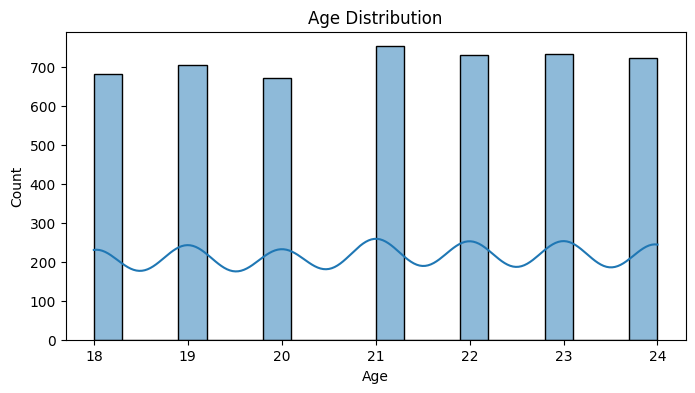

In [32]:
# Distribution of Age
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

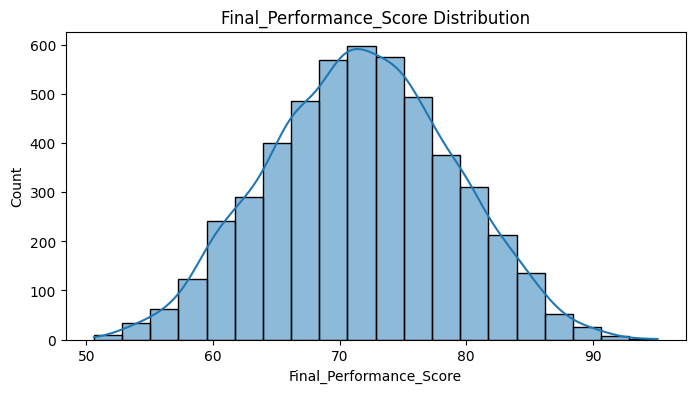

In [33]:
# Distribution of Final_Performance_Score
plt.figure(figsize=(8,4))
sns.histplot(df['Final_Performance_Score'], bins=20, kde=True)
plt.title("Final_Performance_Score Distribution")
plt.show()

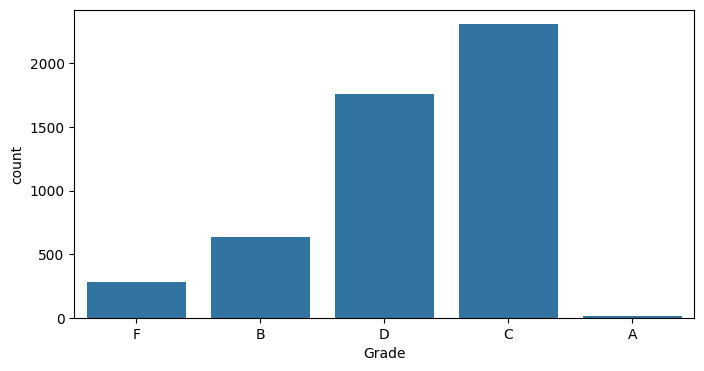

In [34]:
# Grade Count
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Grade')
plt.show()

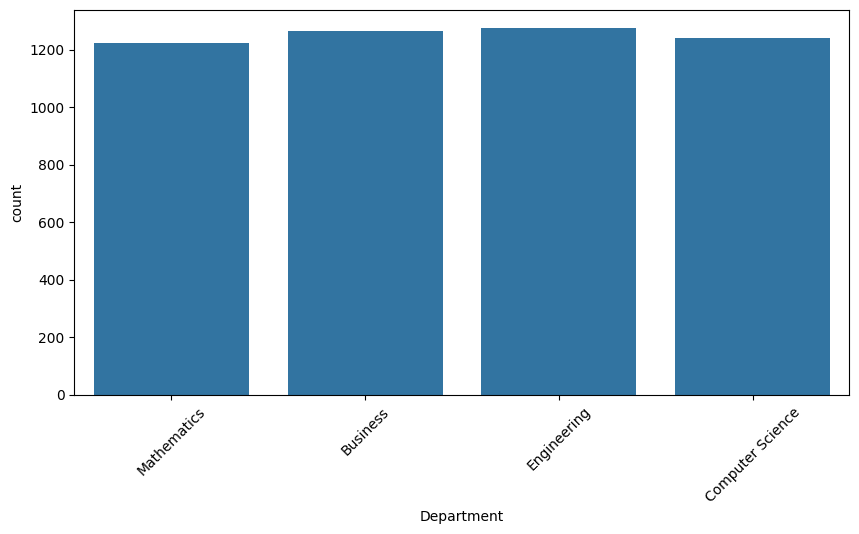

In [35]:
# Department Distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Department')
plt.xticks(rotation=45)
plt.show()

#### Grade Analysis

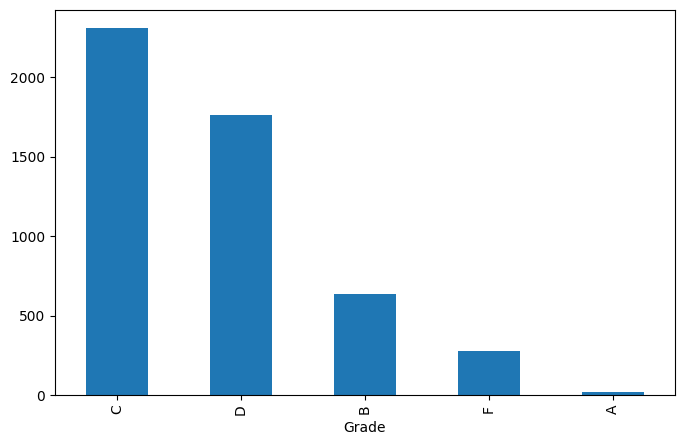

In [36]:
# Grade Distribution
grade_counts = df['Grade'].value_counts()

plt.figure(figsize=(8,5))
grade_counts.plot(kind='bar')
plt.show()

In [37]:
df.groupby('Grade')['Total_Score'].mean().sort_values()

Grade
F    57.552701
D    65.795618
C    74.515495
B    83.127444
A    91.277375
Name: Total_Score, dtype: float64

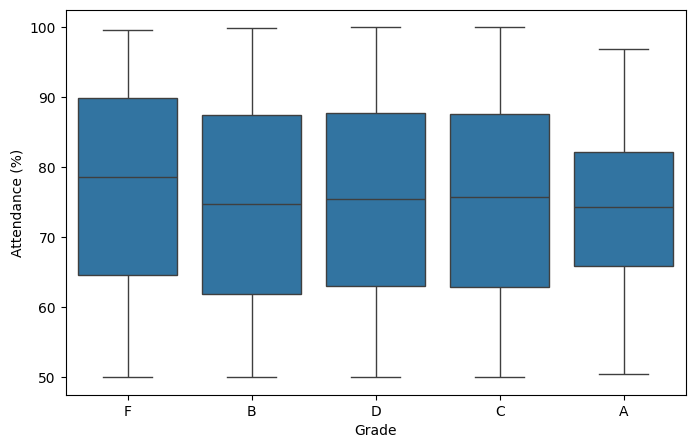

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='Grade',
            y='Attendance (%)')

plt.show()

## 3.2 Bivariate Analysis

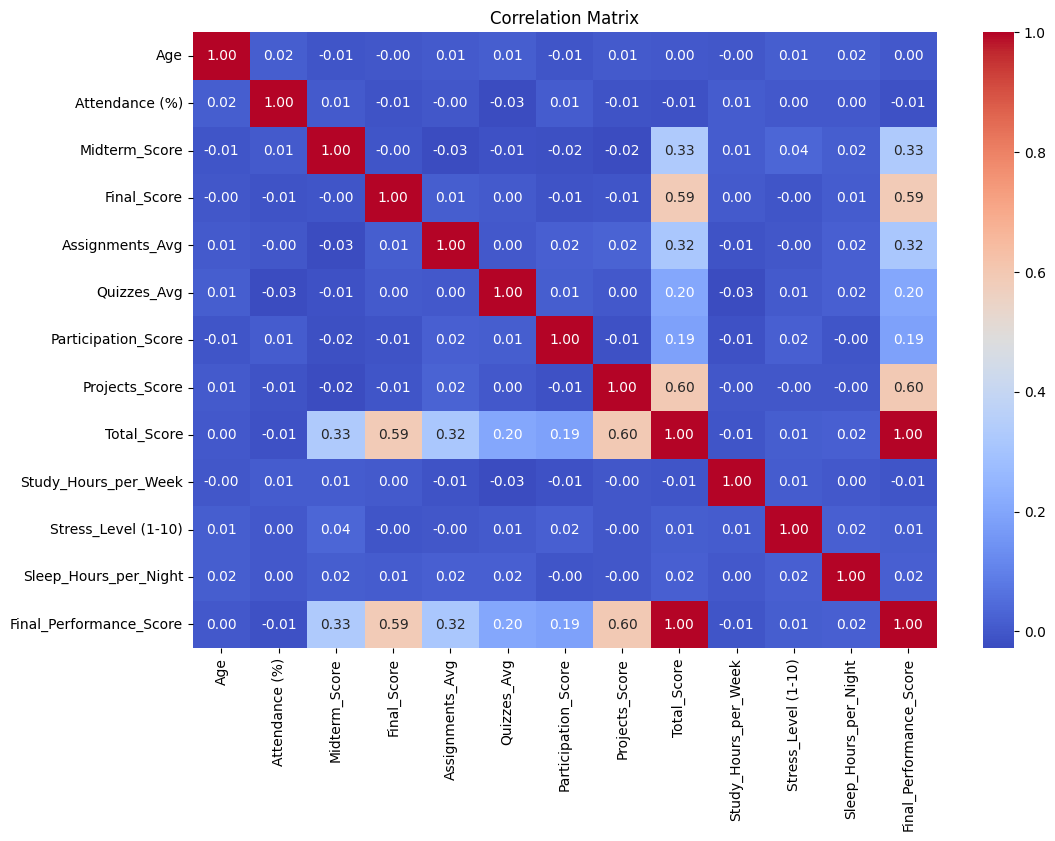

In [39]:
num_df = df.select_dtypes(include=np.number)

corr = num_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

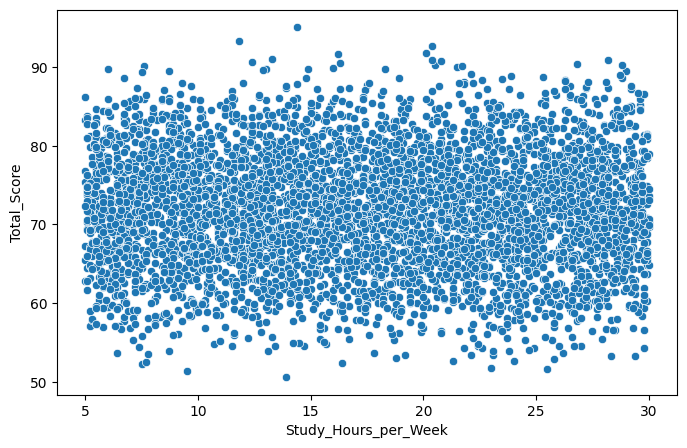

In [40]:
# Study Hours vs Total Score
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='Study_Hours_per_Week',
                y='Total_Score')

plt.show()

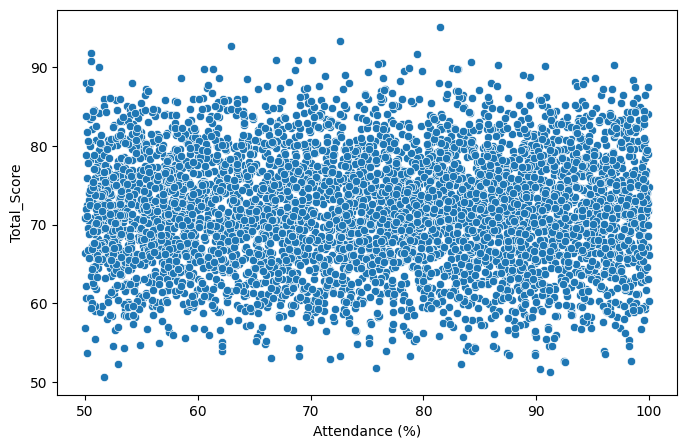

In [41]:
# Attendance vs Total Score
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x='Attendance (%)',
                y='Total_Score')

plt.show()

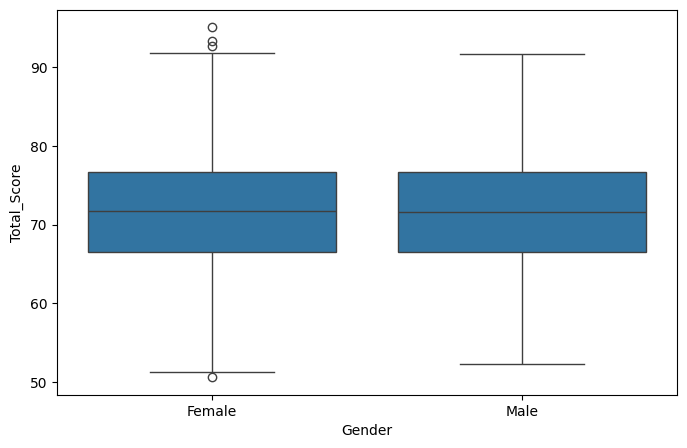

In [42]:
# Gender vs Total Score
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x='Gender',
            y='Total_Score')

plt.show()

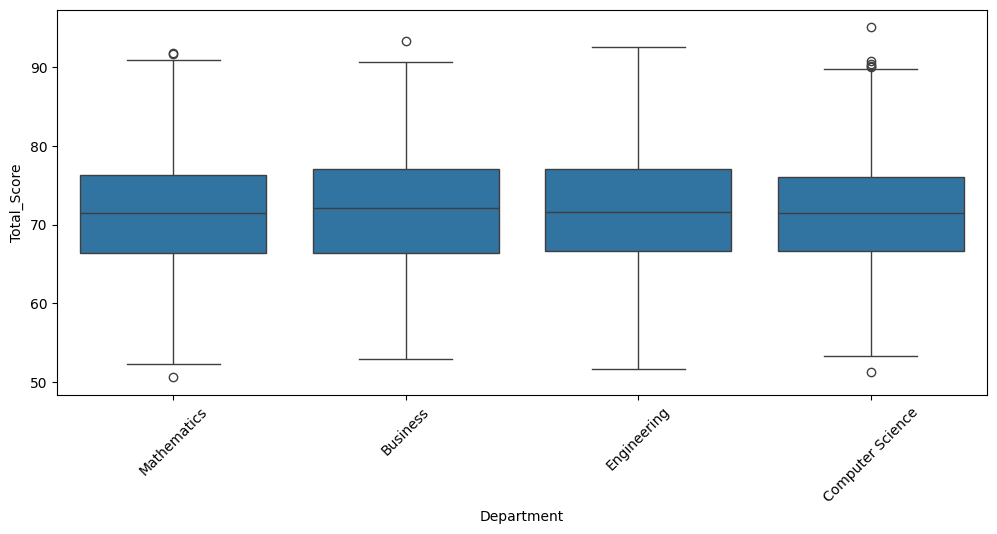

In [43]:
# Department vs Total Score
plt.figure(figsize=(12,5))
sns.boxplot(data=df,
            x='Department',
            y='Total_Score')

plt.xticks(rotation=45)
plt.show()

# 4. Hypothesis Testing

In [44]:
from scipy import stats

In [45]:
def interpretation(p_value:float) -> str:
    if p_value < 0.05:
        return "Reject H0"
    else:
        return "Fail to Reject H0"

#### Test 1: Gender affects Total Score?<br>
H0 - Male and Female students have same average final performance score.<br>
H1 - Average scores are different.

In [46]:
male = df[df['Gender']=='Male']['Final_Performance_Score']
female = df[df['Gender']=='Female']['Final_Performance_Score']

t_stat, gender_p = stats.ttest_ind(male, female)

print("P-value:", gender_p)

P-value: 0.940546284999684


In [47]:
print(interpretation(gender_p))

Fail to Reject H0


#### Test 2: Internet Access affects Final Performance Score?

In [48]:
yes = df[df['Internet_Access_at_Home']=='Yes']['Final_Performance_Score']
no = df[df['Internet_Access_at_Home']=='No']['Final_Performance_Score']

t_stat, internet_p = stats.ttest_ind(yes, no)

print("P-value:", internet_p)

P-value: 0.5815467166815155


In [49]:
print(interpretation(internet_p))

Fail to Reject H0


#### Test 3: Extracurricular Activities affect Final Performance Score?

In [50]:
yes = df[df['Extracurricular_Activities']=='Yes']['Final_Performance_Score']
no = df[df['Extracurricular_Activities']=='No']['Final_Performance_Score']

t_stat, extra_p = stats.ttest_ind(yes, no)

print("P-value:", extra_p)

P-value: 0.8006448332682544


In [51]:
print(interpretation(extra_p))

Fail to Reject H0


#### Test 4: Department affects Final Performance Score?

Since there are multiple departments, use **ANOVA.**

In [52]:
groups = []

for dept in df['Department'].unique():
    groups.append(
        df[df['Department']==dept]['Final_Performance_Score']
    )

f_stat, department_p = stats.f_oneway(*groups)

print("P-value:", department_p)
print(interpretation(department_p))

P-value: 0.3682090116214707
Fail to Reject H0


#### Test 5: Family Income affects Total Score?

In [53]:
groups = []

for income in df['Family_Income_Level'].unique():
    groups.append(
        df[df['Family_Income_Level']==income]['Total_Score']
    )

f_stat, income_p = stats.f_oneway(*groups)

print("P-value:", income_p)
print(interpretation(income_p))

P-value: 0.7191913535294695
Fail to Reject H0


#### Test 6: Parent Education affects Final Performance Score?

In [54]:
groups = []

for edu in df['Parent_Education_Level'].unique():
    groups.append(
        df[df['Parent_Education_Level']==edu]['Final_Performance_Score']
    )

f_stat, parent_p = stats.f_oneway(*groups)

print("P-value:", parent_p)
print(interpretation(parent_p))

P-value: 0.6810895124406746
Fail to Reject H0


#### Test 7: Study Hours Correlation

In [55]:
corr, study_hours_p = stats.pearsonr(
    df['Study_Hours_per_Week'],
    df['Final_Performance_Score']
)

print("Correlation:", corr)
print("P-value:", study_hours_p)

Correlation: -0.006609239950222882
P-value: 0.6403338356450748


In [56]:
print(interpretation(study_hours_p))

Fail to Reject H0


# 5. Final Talble for Conclusion

In [57]:
tests = [
    ('Gender', gender_p),

    ('Internet Access', internet_p),

    ('Extracurricular Activities', extra_p),

    ('Department', department_p),

    ('Family Income', income_p),

    ('Parent Education', parent_p),

    ('Study Hours Correlation', study_hours_p)
]

results_df = pd.DataFrame(
    tests,
    columns=['Test', 'P_Value']
)

results_df['Significant'] = results_df['P_Value'] < 0.05

results_df

,Test,P_Value,Significant
0,Gender,0.940546,False
1,Internet Access,0.581547,False
2,Extracurricular Activities,0.800645,False
3,Department,0.368209,False
4,Family Income,0.719191,False
5,Parent Education,0.681090,False
6,Study Hours Correlation,0.640334,False
